## Create symmetric beam map

In [8]:
#%matplotlib widget
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import timeit
import importlib
import os

import functions_rot as frot
import functions_beams as fbeams
import functions_alms as falms

from scipy.interpolate import RBFInterpolator
#from matplotlib.colors import SymLogNorm
#from matplotlib.ticker import FormatStrFormatter, LogLocator


In [9]:
importlib.reload(frot)
importlib.reload(fbeams)
importlib.reload(falms)

<module 'functions_alms' from '/home/evanetti/BEAMS/beams_code/functions_alms.py'>

In [3]:
# Settings
freq='70GHz' # '30GHz'   '70GHz', '143GHz'
check_time=False  #run Timing portion of notebook
wrt=True  #write symm beam map to FITS file 

### Read beam

In [4]:
map_beam, v1c = fbeams.read_beam(freq, printtext=True)
nside=hp.get_nside(map_beam)


#get rotation quantities:
angdistR=fbeams.beam_radius(map_beam, v1c)
print('\nbeam dimension (rad) = ', angdistR )
v1, beam1 = frot.beam_grid(map_beam, v1c, angdistR)
interpolator0 = RBFInterpolator(v1.T, beam1, kernel='cubic')

Beam file:  beams_070_2247339.fits
Nside =  1024

Beam center:
- center pixel idx =  2247339
- center lonlat (phi,theta) =  (60.029296875, 39.98433353062975)
- center vector = [0.38277074 0.66376194 0.64257812]
Normalization factor =  0.9910121240031213
Normalized beam integral =  0.9999999999999998

beam dimension (rad) =  0.015248735030958454
724 pixels used for interpolation


### Create symmetric beam

create beam at the same position

724  pixels inside defined beam radius
symmetric beam max:  59910.238887141255
original beam max:  59100.12206855254


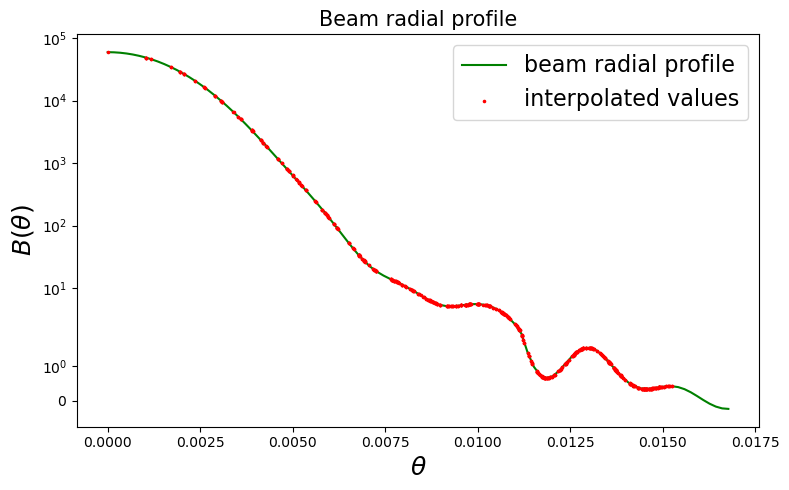

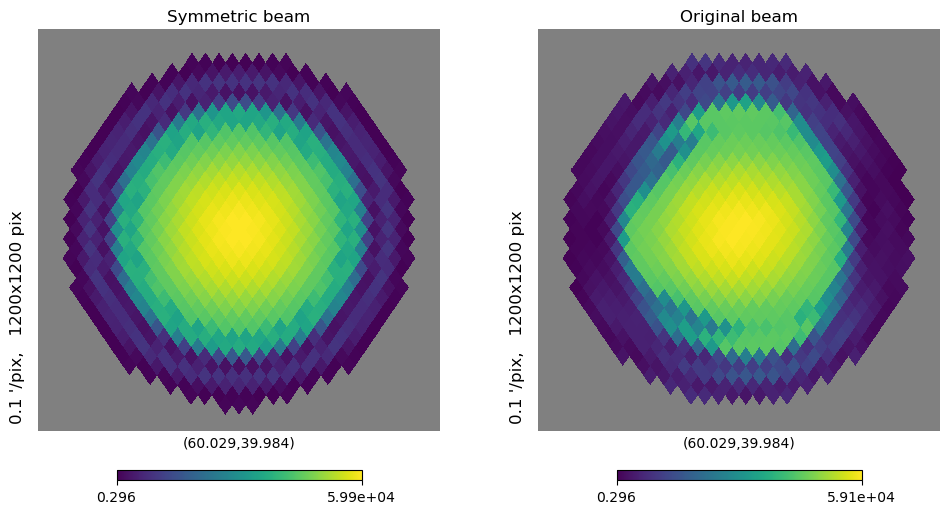

In [5]:
map_beam_symm = fbeams.symmetrize_beam(map_beam, v1c, plot=True)

In [ ]:
if wrt==True:
    dir_name='/home/evanetti/BEAMS/code_products/'
    fname="map_beam_symm_"+str(freq)+".fits"
    fpath=dir_name+fname

    if os.path.exists(fpath):
        print('symmetric beam map FITS file aready exisis')
        
    else:
        hp.write_map(fpath, map_beam_symm, overwrite=False)
        print('symmetric beam map saved as: '+fname)

symmetric beam map FITS file aready exisis


Max value: 59100.12206855254 original map	59910.238887141255 rotated map	 difference = 810.1168185887145	rel difference = 1.3707532069883517%

1-order moment: In1=1.0000000000000004	In2=0.9999861014182214	difference = 1.3898581779026031e-05	rel difference = 0.0013898581779026025 %
2-order moment: In1=29821.232678181823	In2=29821.247984286438	difference = -0.015306104614865035	rel difference = -5.1326196941763166e-05 %
3-order moment: In1=1182808252.5932684	In2=1194823231.777108	difference = -12014979.18383956	rel difference = -1.0158010951899525 %
4-order moment: In1=52622356259535.375	In2=53805018547595.25	difference = -1182662288059.875	rel difference = -2.247452170759784 %
5-order moment: In1=2.4937883453705687e+18	In2=2.5826925733209324e+18	difference = -8.890422795036365e+16	rel difference = -3.5650270046134476 %

Cls factional difference at l=0 2.7796969398018997e-05


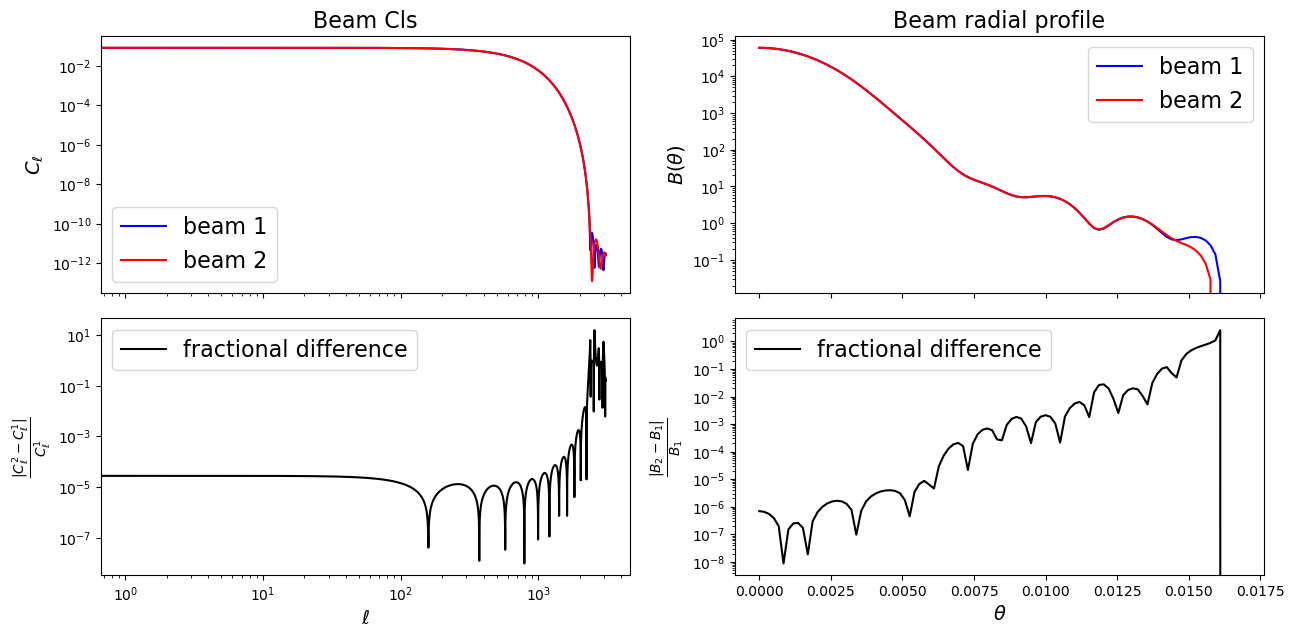

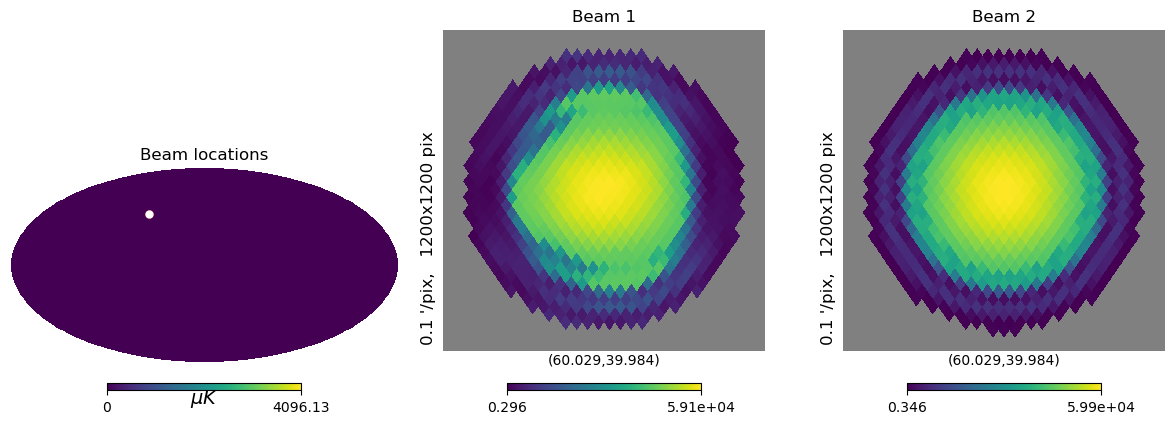

difference map (min,max) =  -4081.670435739754 3529.779238633655
relative difference map (min,max) =  -75.25051669045456 % , 341.34793443172487%


<Figure size 500x500 with 0 Axes>

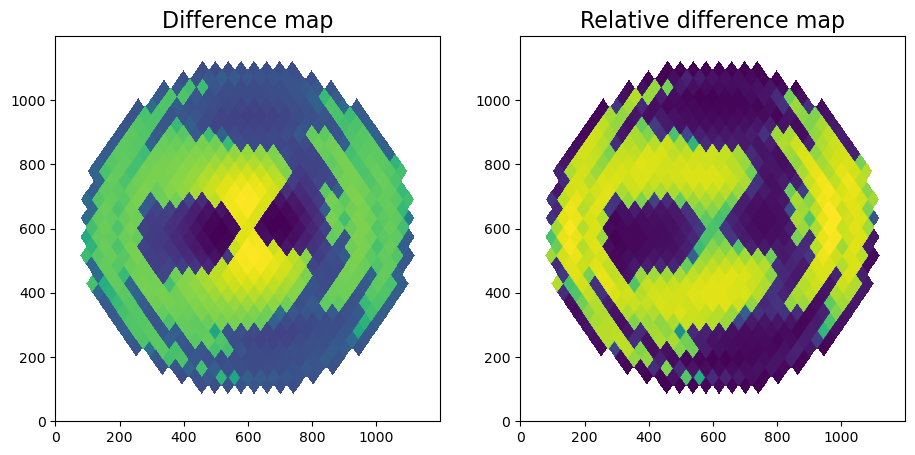

In [7]:
x=fbeams.compare_beams(v1c, v1c, map_beam, map_beam_symm)

ADD alm analysis on symmetric beam map: (compared to initial one)
- rotate to pole
- plot alms ditribution 